In [20]:
import pandas as pd

In [4]:
import os
os.getcwd()

'C:\\Users\\gopia\\OneDrive\\Desktop\\telco-churn-analytics\\data\\notebooks'

In [5]:
os.listdir("..")

['notebooks', 'Telco-Customer-Churn.csv.csv']

In [6]:
os.listdir("../data")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data'

In [21]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [22]:
df.shape

(7043, 50)

In [12]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [23]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')

In [24]:
df.dtypes

Customer ID                           object
Gender                                object
Age                                    int64
Under 30                              object
Senior Citizen                        object
Married                               object
Dependents                            object
Number of Dependents                   int64
Country                               object
State                                 object
City                                  object
Zip Code                               int64
Latitude                             float64
Longitude                            float64
Population                             int64
Quarter                               object
Referred a Friend                     object
Number of Referrals                    int64
Tenure in Months                       int64
Offer                                 object
Phone Service                         object
Avg Monthly Long Distance Charges    float64
Multiple L

In [25]:
df.isna().sum().sort_values(ascending=False)

Churn Reason                         5174
Churn Category                       5174
Offer                                3877
Internet Type                        1526
Payment Method                          0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                        0
Streaming Music                         0
Unlimited Data                          0
Contract                                0
Paperless Billing                       0
Monthly Charge                          0
Online Security                         0
Total Charges                           0
Total Refunds                           0
Total Extra Data Charges                0
Total Long Distance Charges             0
Total Revenue                           0
Satisfaction Score                      0
Customer Status                         0
Churn Label                             0
Churn Score                       

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [29]:
df.shape

(7043, 50)

In [30]:
df.isna().sum().sort_values(ascending=False).head(10)

Churn Reason              5174
Churn Category            5174
Offer                     3877
Internet Type             1526
Payment Method               0
Device Protection Plan       0
Premium Tech Support         0
Streaming TV                 0
Streaming Movies             0
Streaming Music              0
dtype: int64

In [31]:
df["Contract"].value_counts()

Contract
Month-to-Month    3610
Two Year          1883
One Year          1550
Name: count, dtype: int64

In [32]:
churn_rate = (df["Churn Label"] == "Yes").mean() * 100
print("Churn Rate:", round(churn_rate,2), "%")

Churn Rate: 26.54 %


In [33]:
df.groupby("Contract")["Churn Label"].value_counts(normalize=True).unstack()*100

Churn Label,No,Yes
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


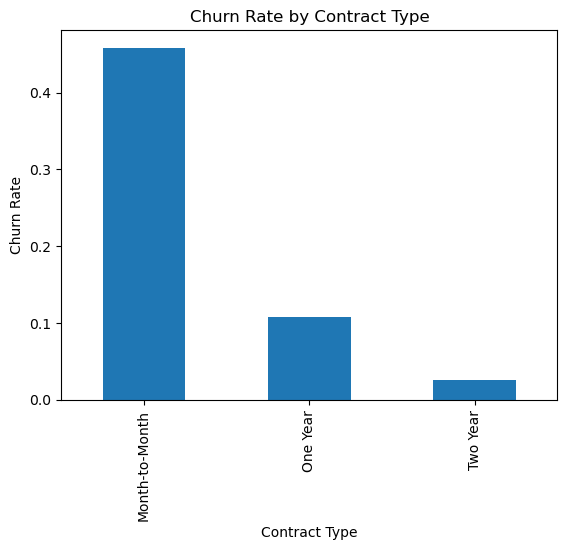

In [34]:
import matplotlib.pyplot as plt

churn_contract = df.groupby("Contract")["Churn Label"].value_counts(normalize=True).unstack()

churn_contract["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.show()

In [35]:
df["Tenure Group"] = pd.cut(
    df["Tenure in Months"],
    bins=[0,6,12,24,48,72],
    labels=["0-6","7-12","13-24","25-48","49-72"]
)

In [36]:
df.groupby("Tenure Group")["Churn Label"].value_counts(normalize=True).unstack()*100

C:\Users\gopia\AppData\Local\Temp\ipykernel_6680\2790389761.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure Group")["Churn Label"].value_counts(normalize=True).unstack()*100


Churn Label,No,Yes
Tenure Group,,
0-6,46.666667,53.333333
7-12,64.664804,35.335196
13-24,71.289062,28.710938
25-48,79.611041,20.388959
49-72,90.486824,9.513176


C:\Users\gopia\AppData\Local\Temp\ipykernel_6680\1174802670.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_tenure = df.groupby("Tenure Group")["Churn Label"].value_counts(normalize=True).unstack()


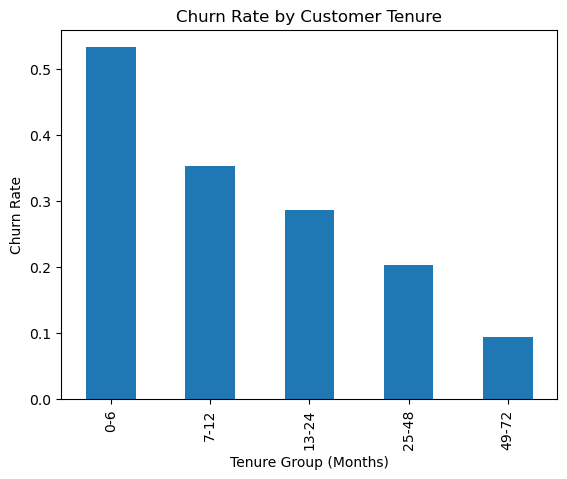

In [37]:
import matplotlib.pyplot as plt

churn_tenure = df.groupby("Tenure Group")["Churn Label"].value_counts(normalize=True).unstack()

churn_tenure["Yes"].plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group (Months)")
plt.show()

In [38]:
df.groupby("Satisfaction Score")["Churn Label"].value_counts(normalize=True).unstack()*100

Churn Label,No,Yes
Satisfaction Score,,
1,NaN,100.000000
2,NaN,100.000000
3,83.902439,16.097561
4,100.000000,NaN
5,100.000000,NaN


In [39]:
df[df["Churn Label"]=="Yes"]["Churn Reason"].value_counts().head(10)

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64

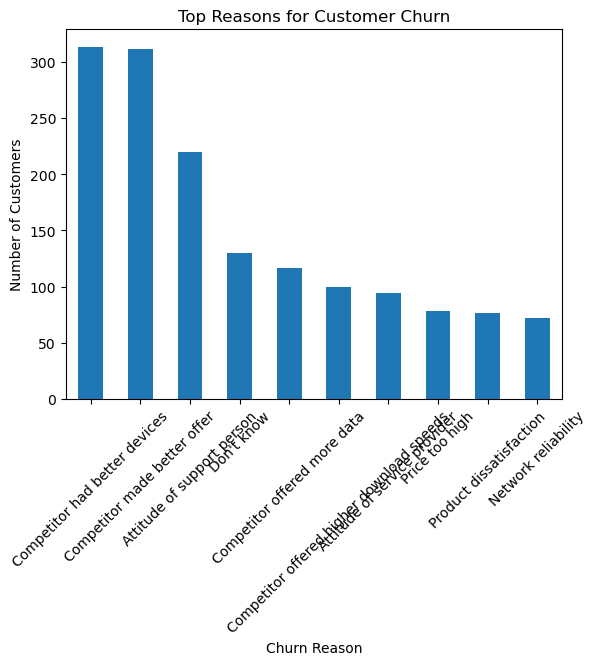

In [40]:
import matplotlib.pyplot as plt

churn_reasons = df[df["Churn Label"]=="Yes"]["Churn Reason"].value_counts().head(10)

churn_reasons.plot(kind="bar")

plt.title("Top Reasons for Customer Churn")
plt.ylabel("Number of Customers")
plt.xlabel("Churn Reason")
plt.xticks(rotation=45)
plt.show()

In [41]:
revenue_at_risk = df.loc[df["Churn Label"]=="Yes","Monthly Charge"].sum()
print("Monthly Revenue at Risk: $", round(revenue_at_risk,2))

Monthly Revenue at Risk: $ 139130.85


In [ ]:
df.to_csv("../data/telco_cleaned.csv", index=False)

## Key Findings

1. The overall customer churn rate is 26.54%, meaning roughly 1 in 4 customers leave the service.

2. Contract type has a strong influence on churn. Customers with month-to-month contracts have the highest churn rate (~46%), while customers with two-year contracts show very low churn (~2.5%).

3. Customer tenure significantly affects churn behavior. Customers within their first 6 months have a churn rate of over 53%, while long-term customers churn much less.

4. Customer satisfaction strongly correlates with churn. Customers with low satisfaction scores are much more likely to leave.

5. The top reasons for churn include competitors offering better devices, better offers, and issues with customer service interactions.

6. Customers who churn represent approximately $139,130 in monthly revenue, highlighting a significant financial impact of customer loss.

## Business Recommendations

1. Encourage customers to move from month-to-month contracts to longer-term contracts through discounts or loyalty incentives.

2. Improve onboarding and engagement during the first 6 months of the customer lifecycle to reduce early churn.

3. Monitor customer satisfaction closely and proactively support customers with low satisfaction scores.

4. Improve competitiveness by offering better device bundles, pricing promotions, and data packages.

5. Invest in customer support training to improve service quality and reduce dissatisfaction-related churn.